# 09 Trace a result

*TRUST*

**Question:** Can I show which inputs produced a result?

- Run the bundled IEEE13 Case twice; compare persisted Case/results and separate attempt IDs.
- Verify each exact run directory before sharing.
- Fingerprints and SHA-256 digests support identity and integrity, not physical correctness or solver authentication.


## ⚙ Runtime — Confirm prerequisites

Use Python 3.10+ with an installed `cept`, or a caller-owned wheel via `CEPT_WHEEL_URL` plus exact `CEPT_WHEEL_SHA256`; the wheel must provide CEPT and OpenDSS. No released PyPI version is assumed. Jupyter is needed only to execute this notebook.

## ⚙ Setup — Initialize the teaching environment

Run the setup cell once to load helpers and check runtime dependencies.

In [1]:
#@title Setup — run once, then read the results below
from hashlib import sha256
from urllib.request import urlopen

_bootstrap_url = "https://raw.githubusercontent.com/sarutesri/cept-studio-edu/main/public/notebooks/_lesson.py"
_bootstrap = urlopen(_bootstrap_url, timeout=60).read()
if sha256(_bootstrap).hexdigest() != "7707385fd5fe60a9bec2e0bdd1bda33bc7b06bab71a8304dff0a7de86d23a0c6":
    raise ValueError("Lesson helper hash mismatch")
exec(compile(_bootstrap, "cept-lesson", "exec"), globals())


CEPT_WHEEL_URL not supplied; using the existing installed environment.
CLI: cept --version


cept-power-studio 0.2.0.dev0


Lesson helpers ready. Stage cells below run the same CEPT commands as a normal terminal.


## ▶ Run — Execute the same Case twice

Run the bundled Case into two separate directories, then verify each exact run. Keep each attempt ID tied to its own outputs; do not select a result by timestamp.


In [2]:
!cept run --demo load-flow \
    --network ieee13 \
    --out runs/05-reproducibility-1 \
    --force \
    --format text

!cept run --demo load-flow \
    --network ieee13 \
    --out runs/05-reproducibility-2 \
    --force \
    --format text

!cept verify runs/05-reproducibility-1 --format text
!cept verify runs/05-reproducibility-2 --format text

CEPT study result: FINISHED
----------------------------
Result             Finished the balanced load flow and saved the evidence
Saved run          runs\05-reproducibility-1
Case fingerprint   748c8026c9d6 (matches the case you ran)

What this means
  The study completed and saved solver-backed evidence.
  It does NOT approve a real project or field installation.

Next
  cept verify runs\05-reproducibility-1 --format text


CEPT study result: FINISHED
----------------------------
Result             Finished the balanced load flow and saved the evidence
Saved run          runs\05-reproducibility-2
Case fingerprint   748c8026c9d6 (matches the case you ran)

What this means
  The study completed and saved solver-backed evidence.
  It does NOT approve a real project or field installation.

Next
  cept verify runs\05-reproducibility-2 --format text


CEPT study check: PASSED
----------------------------
Study              Load flow (OpenDSS)
Case fingerprint   748c8026c9d6 (matches the case you ran)

Checked   3 groups, 14 checks, all passed
  [PASS] Case identity (4 checks)
  [PASS] Solver result (3 checks)
  [PASS] Saved evidence (7 checks)

What this means
  The saved result matches its Case, solver run, and saved evidence.
  It does NOT approve a real project or field installation.

Saved evidence     public-verification.json

For the full check list
  cept verify . --format json


CEPT study check: PASSED
----------------------------
Study              Load flow (OpenDSS)
Case fingerprint   748c8026c9d6 (matches the case you ran)

Checked   3 groups, 14 checks, all passed
  [PASS] Case identity (4 checks)
  [PASS] Solver result (3 checks)
  [PASS] Saved evidence (7 checks)

What this means
  The saved result matches its Case, solver run, and saved evidence.
  It does NOT approve a real project or field installation.

Saved evidence     public-verification.json

For the full check list
  cept verify . --format json


## 🔎 Inspect — Read the receipts (IDs and hashes)

Read `manifest.json`, `results.json`, and `public-verification.json`; fingerprints identify the persisted Case and receipts remain workflow-bounded.


In [3]:
#@title Inspect receipts (optional details)
RUN_ONE = WORKSPACE / "runs" / "05-reproducibility-1"
RUN_TWO = WORKSPACE / "runs" / "05-reproducibility-2"
case_one = read(RUN_ONE / "case.json")
case_two = read(RUN_TWO / "case.json")
result_one = read(RUN_ONE / "results.json")
result_two = read(RUN_TWO / "results.json")
receipt_one = read(RUN_ONE / "public-verification.json")
receipt_two = read(RUN_TWO / "public-verification.json")
table(
    ["run", "case fingerprint", "claim", "verified"],
    [
        ("run 1", receipt_one["case_fingerprint"], receipt_one["claim"], receipt_one["passed"]),
        ("run 2", receipt_two["case_fingerprint"], receipt_two["claim"], receipt_two["passed"]),
    ],
)
assert receipt_one["claim"] == "WORKFLOW_VALIDATED" and receipt_two["claim"] == "WORKFLOW_VALIDATED" 

run    case fingerprint  claim               verified
-----  ----------------  ------------------  --------
run 1  748c8026c9d6      WORKFLOW_VALIDATED  True
run 2  748c8026c9d6      WORKFLOW_VALIDATED  True


## ✓ Verify — Compare persisted payloads

Compare Case and solver payloads across both runs; confirm separate attempt IDs and matching load-flow rows.


In [4]:
#@title Full reproducibility checks + small sample
rows_one = result_one["load_flow"]["bus_voltages"]
rows_two = result_two["load_flow"]["bus_voltages"]
sample_buses = {"sourcebus", "671", "675", "611", "680"}
sample = [row for row in rows_one if row["bus"].lower() in sample_buses]
table(
    ["bus", "phase", "voltage magnitude", "unit"],
    [(row["bus"], row["phase"], row["v_pu"], "pu") for row in sample],
)
print()
print("Same case, run twice")
print("--------------------")
same_inputs = case_one == case_two and result_one["case_fingerprint"] == result_two["case_fingerprint"]
same_answers = result_one["load_flow"] == result_two["load_flow"]
separate_runs = receipt_one["attempt_id"] != receipt_two["attempt_id"]
print(f"Result        {'PASSED' if receipt_one['passed'] and receipt_two['passed'] else 'Needs attention'}")
print(f"Same inputs:  {'yes' if same_inputs else 'no'} (same case, same fingerprint)")
print(f"Same answers: {'yes' if same_answers else 'no'} ({len(rows_one)} voltage points match)")
print(f"Separate runs: {'yes' if separate_runs else 'no'} (two run folders, two receipts)")
assert case_one == case_two
assert result_one["case_fingerprint"] == result_two["case_fingerprint"]
assert result_one["load_flow"] == result_two["load_flow"]
assert receipt_one["attempt_id"] != receipt_two["attempt_id"]
assert receipt_one["passed"] is True and receipt_two["passed"] is True


bus        phase  voltage magnitude  unit
---------  -----  -----------------  ----
sourcebus  1      0.999974           pu
sourcebus  2      0.999994           pu
sourcebus  3      0.99995            pu
671        1      0.982797           pu
671        2      1.040275           pu
671        3      0.964889           pu
675        1      0.976273           pu
675        2      1.042631           pu
675        3      0.962955           pu
611        3      0.960843           pu
680        1      0.982797           pu
680        2      1.040275           pu
680        3      0.964889           pu

Same case, run twice
--------------------
Result        PASSED
Same inputs:  yes (same case, same fingerprint)
Same answers: yes (41 voltage points match)
Separate runs: yes (two run folders, two receipts)


## 📈 Plot — Overlay the two runs

Plot the persisted voltage samples to make any difference visible.


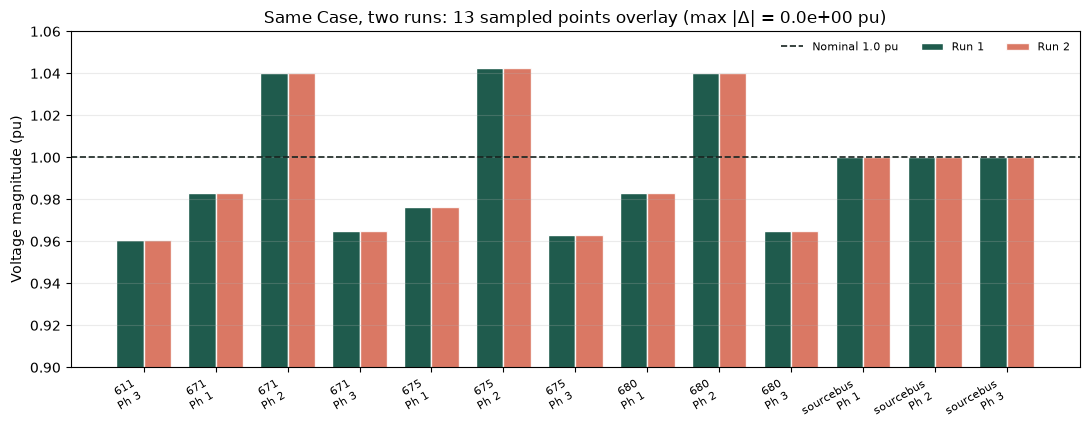

Overlay of 13 sampled points (full check: 41 points in the table cell).


In [5]:
#@title Plot — two runs overlay (identical inputs give identical answers)
import matplotlib.pyplot as plt

lookup_two = {(r["bus"].lower(), int(r["phase"])): float(r["v_pu"]) for r in rows_two}
plot_rows = sorted(sample, key=lambda r: (r["bus"].lower(), int(r["phase"])))
labels = [f"{r['bus']}\nPh {r['phase']}" for r in plot_rows]
v1 = [float(r["v_pu"]) for r in plot_rows]
v2 = [lookup_two[(r["bus"].lower(), int(r["phase"]))] for r in plot_rows]
maxdiff = max(abs(a - b) for a, b in zip(v1, v2)) if v1 else 0.0

x = list(range(len(labels))); w = 0.38
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar([i - w / 2 for i in x], v1, w, label="Run 1", color="#1f5b4d", edgecolor="white")
ax.bar([i + w / 2 for i in x], v2, w, label="Run 2", color="#d5654e", alpha=0.88, edgecolor="white")
ax.axhline(1.0, color="#17231f", linestyle="--", linewidth=1.2, label="Nominal 1.0 pu")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.set_title(f"Same Case, two runs: {len(plot_rows)} sampled points overlay (max |\u0394| = {maxdiff:.1e} pu)")
ax.set_ylabel("Voltage magnitude (pu)")
ax.set_ylim(0.90, 1.06)
ax.legend(frameon=False, ncol=3, fontsize=8); ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
from IPython.display import display
display(fig)
plt.close(fig)
print(f"Overlay of {len(plot_rows)} sampled points (full check: {len(rows_one)} points in the table cell).")


## ◇ Interpret — Separate integrity from physics

Attempt IDs and timestamps identify separate executions; they do not choose an authoritative result. Keep both exact run paths and receipts when sharing. Fingerprints and SHA-256 digests support Case/artifact identity and integrity; they do not prove physical correctness, solver authentication, or project acceptance.